# This notebook demonstrates our Monolingual AES pipeline on the CEDEL2 Spanish dataset and MERCEL German Dataset:
- 
-
-
-



In [ ]:
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error, mean_squared_error, cohen_kappa_score
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 1) Load Data

We apply light cleaning:
- lowercase
- normalize whitespace
- remove punctuation/symbols

Then we compute the score range (1–6) for clipping/rounding.


In [ ]:
path = "aes_spanish.tsv"

df = pd.read_csv(
    path,
    sep="\t",
    engine="python",
    comment="#",
    encoding="utf-8"
)

print(df.shape)
print(df.columns.tolist())


(3034, 41)
['Subcorpus', 'Filename', 'Year data collection', 'Placement test score (raw)', 'Placement test score (%)', 'Proficiency', 'Sex', 'Age', 'School/University/Institution', 'Major', 'Year at university/school', 'L1', "Father's native language", "Mother's nativelanguage", 'Languages spoken at home', 'Age of exposure to Spanish', 'Years studying Spanish', 'Stay abroad in Spanish speaking country (>= 1 month)', 'Stay abroad (where)', 'Stay abroad (when)', 'Stay abroad (months)', 'Language certificates (type and level)', 'Proficiency (self-assessment) speaking', 'Proficiency (self-assessment) listening', 'Proficiency (self-assessment) reading', 'Proficiency (self-assessment) writing', 'Proficiency (self-assessment)', 'Additional foreign language(s)', 'Proficiency (self-assessment) in additional language speaking', 'Proficiency (self-assessment) in additional language listening', 'Proficiency (self-assessment) in additional language reading', 'Proficiency (self-assessment) in additi

In [ ]:

df = df[df["Text"].notna()].copy()

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"<br\s*/?>", " ", text)  
    text = re.sub(r"\s+", " ", text)        
    return text.strip()

df["text_clean"] = df["Text"].apply(clean_text)

df = df[df["text_clean"].str.len() > 30].copy()


df["score_raw"] = (
    df["Proficiency (self-assessment)"]
    .astype(str)
    .str.replace("/ 6", "", regex=False)
    .str.strip()
)

df["score_raw"] = pd.to_numeric(df["score_raw"], errors="coerce")

df = df[df["score_raw"].notna()].copy()

print("After cleaning:")
print(df.shape)
df[["text_clean", "score_raw"]].head(2)


After cleaning:
(3034, 43)


,text_clean,score_raw
0,"Aquel día, había un hombre que siempre pasaba ...",3.0
1,Había un hombre que estaba andando en la calle...,3.5


## 2) Quick EDA

We briefly inspect:
- Score distribution
- Essay length distribution
- Relationship between essay length and score (correlation)


Dataset size: (3034, 43)

Score statistics:
count    3034.000000
mean        3.364370
std         1.318155
min         1.000000
25%         2.000000
50%         3.500000
75%         4.250000
max         6.000000
Name: score_raw, dtype: float64


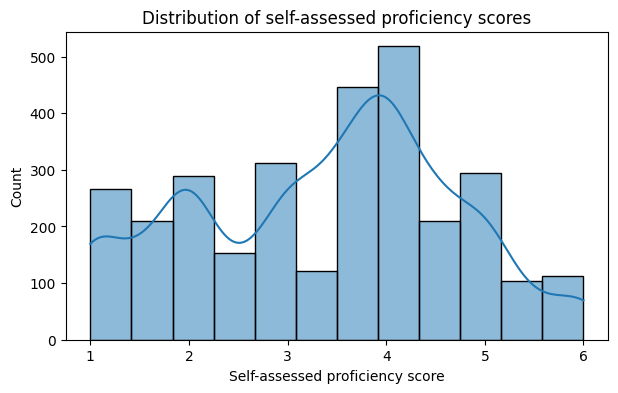


Essay length statistics:
count    3034.000000
mean      244.504285
std       178.627327
min         6.000000
25%        95.000000
50%       183.000000
75%       377.000000
max      1578.000000
Name: essay_length, dtype: float64


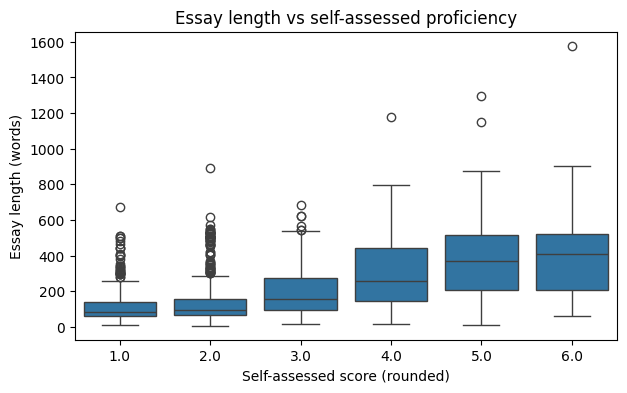


Correlation with placement test score:
                          score_raw  Placement test score (%)
score_raw                  1.000000                  0.678463
Placement test score (%)   0.678463                  1.000000

Correlation between score and essay length:
              score_raw  essay_length
score_raw       1.00000       0.48163
essay_length    0.48163       1.00000


In [ ]:

print("Dataset size:", df.shape)
print("\nScore statistics:")
print(df["score_raw"].describe())

plt.figure(figsize=(7,4))
sns.histplot(df["score_raw"], bins=12, kde=True)
plt.xlabel("Self-assessed proficiency score")
plt.title("Distribution of self-assessed proficiency scores")
plt.show()

df["essay_length"] = df["text_clean"].str.split().str.len()

print("\nEssay length statistics:")
print(df["essay_length"].describe())

plt.figure(figsize=(7,4))
sns.boxplot(x=df["score_raw"].round(), y=df["essay_length"])
plt.xlabel("Self-assessed score (rounded)")
plt.ylabel("Essay length (words)")
plt.title("Essay length vs self-assessed proficiency")
plt.show()

if "Placement test score (%)" in df.columns:
    print("\nCorrelation with placement test score:")
    print(df[["score_raw", "Placement test score (%)"]].corr())

print("\nCorrelation between score and essay length:")
print(df[["score_raw", "essay_length"]].corr())


In [ ]:

df["label"] = df["score_raw"].astype(float)

# Safety clip (scores must stay in 1–6)
df["label"] = df["label"].clip(1, 6)

print(df["label"].describe())


count    3034.000000
mean        3.364370
std         1.318155
min         1.000000
25%         2.000000
50%         3.500000
75%         4.250000
max         6.000000
Name: label, dtype: float64


## 3) Train / Validation / Test Split

We split the dataset into:
- 80% train
- 10% validation
- 10% test

Stratification preserves the score distribution.


In [ ]:


SEED = 42

train_df, temp_df = train_test_split(
    df[["text_clean", "label"]],
    test_size=0.2,
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=SEED
)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)


Train: (2427, 2)
Val: (303, 2)
Test: (304, 2)


In [ ]:


train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df.reset_index(drop=True))
test_ds  = Dataset.from_pandas(test_df.reset_index(drop=True))

train_ds


Dataset({
    features: ['text_clean', 'label'],
    num_rows: 2427
})

## 4) Tokenization

Next we tokenize essays using RoBERTa’s tokenizer and pad to 512 tokens.


In [ ]:


model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

MAX_LEN = 128



def tokenize_batch(batch):
    return tokenizer(
        batch["text_clean"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN
    )

train_ds = train_ds.map(tokenize_batch, batched=True)
val_ds   = val_ds.map(tokenize_batch, batched=True)
test_ds  = test_ds.map(tokenize_batch, batched=True)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/2427 [00:00<?, ? examples/s]

Map:   0%|          | 0/303 [00:00<?, ? examples/s]

Map:   0%|          | 0/304 [00:00<?, ? examples/s]

In [ ]:

# CLEANING DATASET COLUMNS

cols_to_keep = ["input_ids", "attention_mask", "label"]

train_ds = train_ds.remove_columns(
    [c for c in train_ds.column_names if c not in cols_to_keep]
)
val_ds = val_ds.remove_columns(
    [c for c in val_ds.column_names if c not in cols_to_keep]
)
test_ds = test_ds.remove_columns(
    [c for c in test_ds.column_names if c not in cols_to_keep]
)

train_ds[0]


{'label': 6.0,
 'input_ids': [0,
  7950,
  143561,
  121,
  88,
  12084,
  3224,
  8166,
  163,
  25975,
  11,
  4273,
  158,
  51,
  101862,
  22,
  12879,
  50547,
  1919,
  27868,
  3296,
  5,
  67887,
  43250,
  80226,
  11544,
  121,
  520,
  136310,
  8,
  26875,
  65398,
  22,
  216279,
  5,
  1215,
  102096,
  15275,
  5745,
  22,
  21,
  25317,
  473,
  36,
  22,
  21946,
  57329,
  164,
  5,
  262,
  3594,
  43250,
  22,
  158115,
  113,
  34771,
  110062,
  38035,
  282,
  9877,
  3757,
  22,
  216279,
  224,
  104272,
  30418,
  20034,
  8,
  25975,
  28004,
  110,
  40,
  5171,
  53290,
  22,
  21,
  26137,
  14997,
  3812,
  8444,
  40,
  25975,
  11,
  5,
  56152,
  15275,
  26080,
  11544,
  8444,
  110,
  50239,
  41,
  55688,
  10764,
  3757,
  110,
  163,
  27427,
  4,
  163,
  27427,
  1005,
  21,
  178964,
  5,
  4228,
  2366,
  41,
  32498,
  21,
  63602,
  113,
  41,
  158,
  13350,
  11544,
  4,
  41408,
  4681,
  11100,
  146553,
  557,
  5,
  2369,
  764,
  14

## 5) Model: RoBERTa Regression

We fine-tune RoBERTa-base with a regression head:
- `num_labels=1`
- `problem_type="regression"`

The model predicts a **continuous score**, which we later round to the range [1, 6].


In [ ]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=1,
    problem_type="regression"
).to(device)

model


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


XLMRobertaForSequenceClassification(
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=

## 6) Metrics

We report:
- Accuracy (rounded predictions)
- QWK (Quadratic Weighted Kappa)
- Pearson correlation
- MAE
- RMSE


In [ ]:


def compute_metrics(eval_pred):
    preds, labels = eval_pred

    preds = preds.squeeze()

    preds_rounded = np.clip(np.round(preds), 1, 6).astype(int)
    labels_rounded = np.clip(np.round(labels), 1, 6).astype(int)

    qwk = cohen_kappa_score(
        labels_rounded,
        preds_rounded,
        weights="quadratic"
    )

    mae = mean_absolute_error(labels, preds)
    rmse = np.sqrt(mean_squared_error(labels, preds))
    pearson = pearsonr(labels, preds)[0]

    return {
        "qwk": qwk,
        "mae": mae,
        "rmse": rmse,
        "pearson": pearson
    }


## 7) Training Setup

We fine-tune with:
- LR = 2e-5
- 3 epochs
- FP16 on GPU
- Evaluate + save every 500 steps
- Load best checkpoint based on **QWK**


In [ ]:


training_args = TrainingArguments(
    output_dir="./xlmr_spanish_aes",
    learning_rate=2e-5,
    num_train_epochs=3,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,  # effective batch = 2*4 = 8

    weight_decay=0.01,

    eval_strategy="epoch",
    eval_steps=500,
    save_strategy="epoch",
    save_steps=500,
    save_total_limit=2,

    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_qwk",
    greater_is_better=True,

    fp16=False,        
    bf16=False,
    report_to="none"
)




trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer


/tmp/ipython-input-2185648923.py:42: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Qwk,Mae,Rmse,Pearson
1,1.335200,1.118742,0.516778,0.814655,1.057706,0.645442
2,0.945800,1.030007,0.591214,0.790554,1.014892,0.678531
3,0.857200,1.278627,0.577392,0.884002,1.130764,0.677888


TrainOutput(global_step=912, training_loss=1.2922998572650708, metrics={'train_runtime': 429.4453, 'train_samples_per_second': 16.954, 'train_steps_per_second': 2.124, 'total_flos': 478923598418688.0, 'train_loss': 1.2922998572650708, 'epoch': 3.0})

In [ ]:
trainer.save_model("./xlmr_spanish_aes_best")
tokenizer.save_pretrained("./xlmr_spanish_aes_best")


('./xlmr_spanish_aes_best/tokenizer_config.json',
 './xlmr_spanish_aes_best/special_tokens_map.json',
 './xlmr_spanish_aes_best/sentencepiece.bpe.model',
 './xlmr_spanish_aes_best/added_tokens.json',
 './xlmr_spanish_aes_best/tokenizer.json')

## 9) Final Evaluation on Test Set


In [ ]:

test_metrics = trainer.evaluate(test_ds)
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")


eval_loss: 0.9165
eval_qwk: 0.5617
eval_mae: 0.7352
eval_rmse: 0.9574
eval_pearson: 0.6395
eval_runtime: 2.5303
eval_samples_per_second: 120.1420
eval_steps_per_second: 60.0710
epoch: 3.0000


## Confusion Matrix (Rounded Predictions)

The confusion matrix below compares **true essay scores** with **rounded model predictions**.

In [ ]:

# Predictions
preds = trainer.predict(test_ds)

# True labels 
y_true = np.clip(
    np.round(preds.label_ids),
    MIN_SCORE,
    MAX_SCORE
).astype(int)

# Predicted labels
y_pred = np.clip(
    np.round(preds.predictions.squeeze(-1)),
    MIN_SCORE,
    MAX_SCORE
).astype(int)

cm = confusion_matrix(y_true, y_pred)
cm



array([[ 0, 15,  5,  2,  1,  0],
       [ 0, 35, 18,  7,  0,  0],
       [ 0, 13, 15, 18,  1,  0],
       [ 0, 13, 40, 64, 16,  0],
       [ 0,  2,  1, 17, 15,  0],
       [ 0,  0,  1,  3,  2,  0]])

## 10) Scoring an essay sample

We take a raw essay, clean + tokenize it, and get:
- continuous score
- rounded score in range [1, 6]


In [ ]:

def score_essay(text):
    enc = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        score = model(**enc).logits.item()

    return {
    "raw_score": score,
    "final_score": int(np.clip(round(score), MIN_SCORE, MAX_SCORE)),
    "confidence_band": (score - 0.5, score + 0.5)
}



sample_text = df["text_clean"].iloc[0]
score_essay(sample_text)


{'raw_score': 3.0673410892486572,
 'final_score': 3,
 'confidence_band': (2.5673410892486572, 3.5673410892486572)}

# Using German Dataset Now

In [ ]:

GERMAN_TXT_DIR = "german_raw"   # folder containing .txt files
OUTPUT_TSV = "aes_german.tsv"

CEFR_MAP = {
    "A1": 1,
    "A2": 2,
    "B1": 3,
    "B2": 4,
    "C1": 5,
    "C2": 6
}

rows = []


for fname in os.listdir(GERMAN_TXT_DIR):
    if not fname.endswith(".txt"):
        continue

    path = os.path.join(GERMAN_TXT_DIR, fname)

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        content = f.read()

    
    cefr_match = re.search(
        r"Overall CEFR rating:\s*(A1|A2|B1|B2|C1|C2)",
        content
    )
    if not cefr_match:
        continue

    cefr_label = cefr_match.group(1)
    score = CEFR_MAP[cefr_label]

   
    text_match = re.search(
        r"Learner text:\s*(.*?)\n\s*[-]{5,}",
        content,
        re.DOTALL
    )
    if not text_match:
        continue

    essay_text = text_match.group(1).strip()

  
    essay_text = re.sub(r"\s+", " ", essay_text)

    rows.append({
        "filename": fname,
        "language": "de",
        "cefr": cefr_label,
        "score": score,
        "text": essay_text
    })


df_german = pd.DataFrame(rows)

print("German AES samples:", df_german.shape)
df_german.head()

df_german.to_csv(OUTPUT_TSV, sep="\t", index=False)
print(f"Saved → {OUTPUT_TSV}")


German AES samples: (1033, 5)
Saved → aes_german.tsv


In [ ]:


df = pd.read_csv("aes_german.tsv", sep="\t")
df["score"] = df["score"].astype(float)


print(df.shape)
df.head()


(1033, 5)


,filename,language,cefr,score,text
0,1091_0000163.txt,de,A2,2.0,Guten Tag meine Freundin Maria! Ich habe eine ...
1,1071_0248308.txt,de,A2,2.0,"Sehr Liebe Daniela, ich möchte heute Abend ins..."
2,1031_0003149.txt,de,B2,4.0,Uberall werden Sprachen gesprochen und im Beso...
3,1023_0109917.txt,de,B2,4.0,"Maria Müller, Zentralplatz 12 12345 Stadt X SL..."
4,1061_0120358.txt,de,A2,2.0,28/2/2012 Stadt X Liebe Silke Gestern habe ich...


In [ ]:


def clean_text(text):
    text = text.lower()
    text = re.sub(r"-unreadable-", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["text"] = df["text"].astype(str).apply(clean_text)


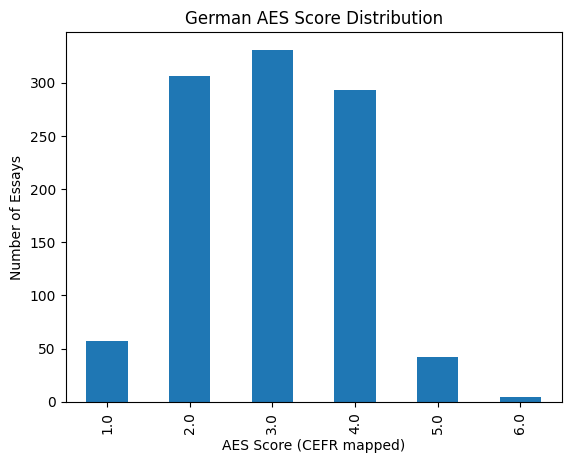

,text
count,1033.000000
mean,758.916747
std,475.855672
min,42.000000
25%,340.000000
50%,608.000000
75%,1161.000000
max,2562.000000


In [ ]:


df["score"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("AES Score (CEFR mapped)")
plt.ylabel("Number of Essays")
plt.title("German AES Score Distribution")
plt.show()

df["text"].str.len().describe()


In [ ]:


# First split: stratified
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["score"]
)

# Second split: NOT stratified
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)

print(len(train_df), len(val_df), len(test_df))

print("Train:\n", train_df["score"].value_counts().sort_index())
print("Val:\n", val_df["score"].value_counts().sort_index())
print("Test:\n", test_df["score"].value_counts().sort_index())


826 103 104
Train:
 score
1.0     45
2.0    245
3.0    265
4.0    234
5.0     34
6.0      3
Name: count, dtype: int64
Val:
 score
1.0     8
2.0    34
3.0    31
4.0    27
5.0     3
Name: count, dtype: int64
Test:
 score
1.0     4
2.0    27
3.0    35
4.0    32
5.0     5
6.0     1
Name: count, dtype: int64


In [ ]:


train_ds = Dataset.from_pandas(train_df[["text", "score"]])
val_ds   = Dataset.from_pandas(val_df[["text", "score"]])
test_ds  = Dataset.from_pandas(test_df[["text", "score"]])

train_ds = train_ds.rename_column("score", "labels")
val_ds   = val_ds.rename_column("score", "labels")
test_ds  = test_ds.rename_column("score", "labels")


In [ ]:
MAX_LEN = 256

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN
    )

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

train_ds.set_format("torch")
val_ds.set_format("torch")
test_ds.set_format("torch")


Map:   0%|          | 0/826 [00:00<?, ? examples/s]

Map:   0%|          | 0/103 [00:00<?, ? examples/s]

Map:   0%|          | 0/104 [00:00<?, ? examples/s]

In [ ]:


model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=1,
    problem_type="regression"
)


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:


training_args = TrainingArguments(
    output_dir="./xlmr_german_aes",
    learning_rate=2e-5,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_qwk",
    greater_is_better=True,

    fp16=True,
    report_to="none"
)


Using the same metrics as before

In [ ]:


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()


/tmp/ipython-input-1482414042.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Qwk,Mae,Rmse,Pearson
1,No log,0.355186,0.780680,0.475595,0.595975,0.877081
2,No log,0.233341,0.891277,0.398921,0.483054,0.886111
3,No log,0.270044,0.838239,0.427384,0.519658,0.885812


TrainOutput(global_step=312, training_loss=0.8153039981157352, metrics={'train_runtime': 205.8321, 'train_samples_per_second': 12.039, 'train_steps_per_second': 1.516, 'total_flos': 325991670617088.0, 'train_loss': 0.8153039981157352, 'epoch': 3.0})

In [ ]:
test_metrics = trainer.evaluate(test_ds)
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")


eval_loss: 0.2858
eval_qwk: 0.7935
eval_mae: 0.4152
eval_rmse: 0.5346
eval_pearson: 0.8503
eval_runtime: 0.5145
eval_samples_per_second: 202.1310
eval_steps_per_second: 25.2660
epoch: 3.0000


In [ ]:


MIN_SCORE = int(df["score"].min())
MAX_SCORE = int(df["score"].max())

preds = trainer.predict(test_ds)
y_true = preds.label_ids.astype(int)
y_pred = np.clip(
    np.round(preds.predictions.squeeze(-1)),
    MIN_SCORE,
    MAX_SCORE
).astype(int)

cm = confusion_matrix(y_true, y_pred)
cm


array([[ 2,  1,  1,  0,  0,  0],
       [ 3, 19,  5,  0,  0,  0],
       [ 0,  5, 19, 11,  0,  0],
       [ 0,  0,  2, 30,  0,  0],
       [ 0,  0,  0,  5,  0,  0],
       [ 0,  0,  0,  1,  0,  0]])

In [ ]:

MODEL_DIR = "./xlmr_german_aes_best"

trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

print(f"German AES model saved to: {MODEL_DIR}")


KeyboardInterrupt: 